In [1]:
# Set up the Shopee dataset paths
from pathlib import Path
import pandas as pd

DATASET_DIR = Path(r"C:\Users\mahan\Downloads\shopee-product-matching")

TRAIN_PATH = DATASET_DIR / "train.csv"
IMAGE_DIR = DATASET_DIR / "train_images"

train = pd.read_csv(TRAIN_PATH)

print("Train shape:", train.shape)
print("Image directory exists:", IMAGE_DIR.exists())
print("Number of image files:", len(list(IMAGE_DIR.glob("*.jpg"))))

Train shape: (34250, 5)
Image directory exists: True
Number of image files: 32412


## ResNet(Residual Network)

1) It is an CNN designed to understand images

2) ResNet was trained beforehand on ImageNet, a huge image dataset.

3) When we give it an image it will give us a 2048 dimension vector which is known as feature of the image, it is made by internally recognizing shapes,edges,texture,colors,patterns, etc

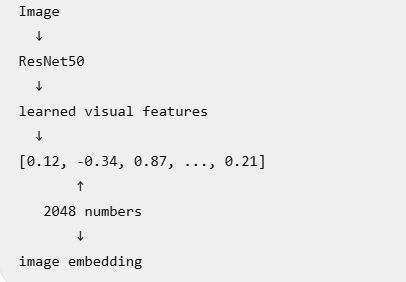

Vector → the mathematical object containing 2048 values

Embedding → that vector as a learned representation of the image

Individual values → components/dimensions of the embedding

In [2]:
# Load ResNet50 as a pretrained image feature extractor
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("Output shape:", resnet.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Output shape: (None, 2048)


### Testing ResNet on one image

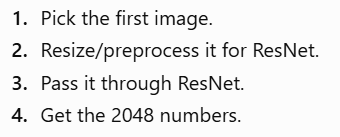

In [ ]:
# Convert one Shopee image into a ResNet embedding
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

image_path = IMAGE_DIR / train.iloc[0]["image"]  

image = load_img(image_path, target_size=(224, 224))  # Pick an image
image_array = img_to_array(image)
image_array = preprocess_input(image_array)
image_array = tf.expand_dims(image_array, axis=0)   # Resize the array

embedding = resnet.predict(image_array, verbose=0)  # Pass it through ResNet

print("Image:", train.iloc[0]["image"])
print("Original array shape:", image_array.shape)
print("Embedding shape:", embedding.shape)
print("First 10 embedding values:", embedding[0][:10])

Image: 0000a68812bc7e98c42888dfb1c07da0.jpg
Original array shape: (1, 224, 224, 3)
Embedding shape: (1, 2048)
First 10 embedding values: [6.81969747e-02 3.38721299e+00 4.28700745e-02 1.02735246e-02
 1.26016617e-01 1.03038594e-01 1.54765043e-03 2.69999146e-01
 2.20164895e-01 3.10113970e-02]


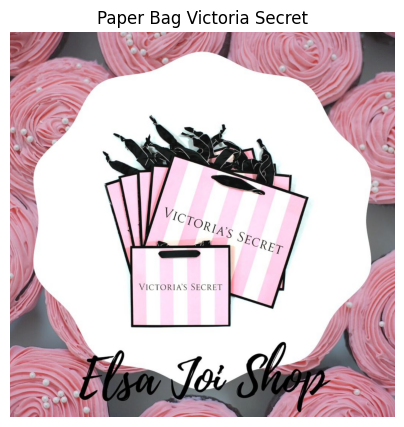

In [4]:
# Display the product image used for the embedding
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(load_img(image_path))
plt.axis("off")
plt.title(train.iloc[0]["title"])
plt.show()

### Generate Embeddings for all images

In [5]:
# Prepare the unique Shopee images for batch embedding
image_names = train["image"].unique()

print("Unique images:", len(image_names))
print("First 5 images:")
print(image_names[:5])

Unique images: 32412
First 5 images:
['0000a68812bc7e98c42888dfb1c07da0.jpg'
 '00039780dfc94d01db8676fe789ecd05.jpg'
 '000a190fdd715a2a36faed16e2c65df7.jpg'
 '00117e4fc239b1b641ff08340b429633.jpg'
 '00136d1cf4edede0203f32f05f660588.jpg']


### We will do Batch embedding (Batch size=32)

In [6]:
# Generate ResNet embeddings for all unique images in batches
import numpy as np

BATCH_SIZE = 32

all_embeddings = []
valid_image_names = []

for start in range(0, len(image_names), BATCH_SIZE):
    batch_names = image_names[start:start + BATCH_SIZE]
    
    batch_images = []
    batch_valid_names = []
    
    for image_name in batch_names:
        image_path = IMAGE_DIR / image_name
        
        try:
            image = load_img(image_path, target_size=(224, 224))
            image_array = img_to_array(image)
            image_array = preprocess_input(image_array)
            
            batch_images.append(image_array)
            batch_valid_names.append(image_name)
        
        except Exception as e:
            print("Failed:", image_name, e)
    
    if batch_images:
        batch_array = np.stack(batch_images)
        batch_embedding = resnet.predict(batch_array, verbose=0)
        
        all_embeddings.append(batch_embedding)
        valid_image_names.extend(batch_valid_names)
    
    if (start // BATCH_SIZE + 1) % 100 == 0:
        print(f"Processed {min(start + BATCH_SIZE, len(image_names))}/{len(image_names)} images")

all_embeddings = np.vstack(all_embeddings)

print("Embedding matrix shape:", all_embeddings.shape)
print("Valid images:", len(valid_image_names))

Processed 3200/32412 images
Processed 6400/32412 images
Processed 9600/32412 images
Processed 12800/32412 images
Processed 16000/32412 images
Processed 19200/32412 images
Processed 22400/32412 images
Processed 25600/32412 images
Processed 28800/32412 images
Processed 32000/32412 images
Embedding matrix shape: (32412, 2048)
Valid images: 32412


In [7]:
# Normalize the ResNet embeddings for cosine similarity
from sklearn.preprocessing import normalize

normalized_embeddings = normalize(
    all_embeddings,
    norm="l2"
)

print("Normalized embedding shape:", normalized_embeddings.shape)
print("First embedding norm:", np.linalg.norm(normalized_embeddings[0]))

Normalized embedding shape: (32412, 2048)
First embedding norm: 0.9999999


### creating positive and negative image-pair dataset

In [8]:
# Create balanced positive and negative image pairs
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# Create one positive pair from each product group
positive_image_pairs = []

for group_id, group in train.groupby("label_group"):
    pair = group.sample(n=2, random_state=42)
    
    positive_image_pairs.append({
        "image_A": pair.iloc[0]["image"],
        "image_B": pair.iloc[1]["image"],
        "actual": 1
    })

positive_image_pairs = pd.DataFrame(positive_image_pairs)

# Create negative pairs from different product groups
negative_image_pairs = []

while len(negative_image_pairs) < len(positive_image_pairs):
    idx_a, idx_b = rng.choice(len(train), size=2, replace=False)
    
    row_a = train.iloc[idx_a]
    row_b = train.iloc[idx_b]
    
    if (
        row_a["label_group"] != row_b["label_group"]
        and row_a["image"] != row_b["image"]
    ):
        negative_image_pairs.append({
            "image_A": row_a["image"],
            "image_B": row_b["image"],
            "actual": 0
        })

negative_image_pairs = pd.DataFrame(negative_image_pairs)

# Combine and shuffle
image_pairs = pd.concat(
    [positive_image_pairs, negative_image_pairs],
    ignore_index=True
)

image_pairs = image_pairs.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Positive pairs:", len(positive_image_pairs))
print("Negative pairs:", len(negative_image_pairs))
print("Total pairs:", len(image_pairs))

Positive pairs: 11014
Negative pairs: 11014
Total pairs: 22028


In [10]:
# Calculate cosine similarity for every image pair
embedding_lookup = {
    image_name: embedding
    for image_name, embedding in zip(valid_image_names, normalized_embeddings)
}

embedding_A = np.stack([
    embedding_lookup[name]
    for name in image_pairs["image_A"]
])

embedding_B = np.stack([
    embedding_lookup[name]
    for name in image_pairs["image_B"]
])

image_similarities = np.sum(
    embedding_A * embedding_B,
    axis=1
)

image_pairs["similarity"] = image_similarities

print("Similarity scores:", len(image_similarities))
print(image_pairs.head(50))

Similarity scores: 22028
                                 image_A  \
0   736262f87ad4eac88edd345c662c592c.jpg   
1   1dc0aa167c763d549915bc6931d1646a.jpg   
2   50afb9420759feff49df2df9234e585e.jpg   
3   68646cc6342bd7889149ee3bf70d445f.jpg   
4   0f6c77ffcece7520c6704f41237b02b7.jpg   
5   73cc8b5883961d0bd0393695f01fd13a.jpg   
6   0cfe50f0694469e996f9b49e907648f8.jpg   
7   ff19d74d5d7f96c91741880d8857f36e.jpg   
8   d718dc3bf2e9d1c5a321de29f5924220.jpg   
9   01caeb4246438a44688e115e43272150.jpg   
10  a4b47b3878c3660ed3e69311b8347889.jpg   
11  fd36151b78e84fa0626fc2d0f87788b2.jpg   
12  cdb1322d001300370fe0cf828d0a6eb7.jpg   
13  50afb9420759feff49df2df9234e585e.jpg   
14  5d6b211ac0789ce2bdd5586422364815.jpg   
15  b0ae6acbc3d6a087eceaab7e0f0adb20.jpg   
16  0719900a777374c3ca65677a66018160.jpg   
17  767ec63b93c6d957ed98a87e057e9da3.jpg   
18  68000edbff831b6f40a8c5312b1dd63b.jpg   
19  b026b6d830b82af5b8fa657ac253e532.jpg   
20  e779cec8268eefa3eb8551d19e14a6fd.jpg   
21  99d

In [11]:
# Compare ResNet similarity distributions for matches and non-matches
positive_image_scores = image_pairs.loc[
    image_pairs["actual"] == 1,
    "similarity"
]

negative_image_scores = image_pairs.loc[
    image_pairs["actual"] == 0,
    "similarity"
]

print("Actual = 1")
print(positive_image_scores.describe())

print("\nActual = 0")
print(negative_image_scores.describe())

Actual = 1
count    11014.000000
mean         0.768613
std          0.173504
min          0.110144
25%          0.639367
50%          0.775293
75%          0.934570
max          1.000001
Name: similarity, dtype: float64

Actual = 0
count    11014.000000
mean         0.408750
std          0.099202
min          0.101219
25%          0.337153
50%          0.400065
75%          0.470241
max          0.843631
Name: similarity, dtype: float64


In [12]:
# Find the best ResNet matching threshold
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.96, 0.02)

resnet_results = []

for threshold in thresholds:
    predictions = (
        image_pairs["similarity"] >= threshold
    ).astype(int)

    precision = precision_score(
        image_pairs["actual"],
        predictions,
        zero_division=0
    )

    recall = recall_score(
        image_pairs["actual"],
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        image_pairs["actual"],
        predictions,
        zero_division=0
    )

    resnet_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

resnet_results = pd.DataFrame(resnet_results)

print(resnet_results.sort_values("f1", ascending=False).head(10))

    threshold  precision    recall        f1
22       0.54   0.896861  0.889777  0.893305
23       0.56   0.919734  0.866624  0.892390
21       0.52   0.870662  0.908843  0.889343
24       0.58   0.937557  0.841111  0.886719
20       0.50   0.840030  0.928273  0.881950
25       0.60   0.952462  0.813147  0.877308
19       0.48   0.807758  0.943436  0.870341
26       0.62   0.964669  0.783367  0.864616
18       0.46   0.773560  0.954694  0.854635
27       0.64   0.974486  0.749047  0.847023


In [13]:
# Inspect the ResNet baseline at the best threshold
from sklearn.metrics import confusion_matrix

best_resnet_threshold = 0.54

resnet_predictions = (
    image_pairs["similarity"] >= best_resnet_threshold
).astype(int)

cm = confusion_matrix(
    image_pairs["actual"],
    resnet_predictions
)

print("Confusion Matrix:")
print(cm)

print("\nTP:", cm[1, 1])
print("FP:", cm[0, 1])
print("TN:", cm[0, 0])
print("FN:", cm[1, 0])

Confusion Matrix:
[[9887 1127]
 [1214 9800]]

TP: 9800
FP: 1127
TN: 9887
FN: 1214


### Observations

- ResNet50 embeddings show a clear separation between positive and negative image pairs. Positive pairs have a much higher average cosine similarity (0.769) than negative pairs (0.409).
- The best threshold was **0.54**, giving an **F1-score of 89.33%**, with **89.69% precision** and **88.98% recall**.
- At this threshold, **9,800 positive pairs** were correctly identified (TP), while **1,214 positive pairs** were missed (FN).
- There were **1,127 false positives**, showing that visually similar but different products can still receive high embedding similarity.
- The results indicate that pretrained ResNet50 features capture useful visual information for product matching without requiring the model to be trained from scratch.
- However, the overlap between positive and negative similarity distributions shows that a single similarity threshold cannot perfectly distinguish product identity in all cases.
- Overall, ResNet50 provides a strong baseline for image-based product matching, but errors are expected for visually similar products, different variants, and images with different backgrounds or packaging.

------------------------------------------------------------------
# Experiment 2:- CLIP

CLIP = Contrastive Language-Image Pre-Training

1) CLIP learns to understand images and text in the same semantic space.

2) CLIP was trained using images + text together

3) During training, CLIP learns:- 

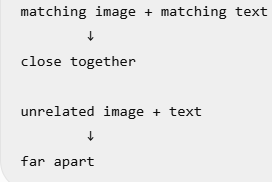


In [14]:
# Check whether Hugging Face Transformers is installed
import transformers

print("Transformers version:", transformers.__version__)

c:\Users\mahan\Venku96200-Intelligence-SIG-Recs-2026\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers version: 5.18.0


In [15]:
# Load the pretrained CLIP model and processor
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)

print("CLIP model loaded")

c:\Users\mahan\Venku96200-Intelligence-SIG-Recs-2026\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mahan\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\mahan\Venku96200-Intelligence-SIG-Recs-2026\.venv\lib\site-packages\hugg

CLIP model loaded


### Testing CLIP embedding on 1 image

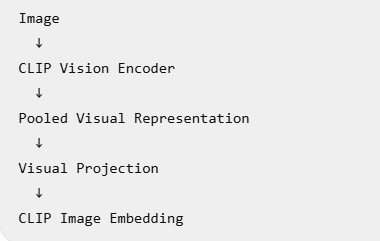

1)**CLIP Vision Encoder**:- This is the actual image-processing neural network inside CLIP.  vision encoder is a Vision Transformer (ViT).
Vision encoder = the part of CLIP that looks at the image and extracts visual information.

2)**Pooled visual representation** :- 
    The vision encoder produces many feature vectors because the image is broken into patches/tokens.
    We don't want to compare hundreds of vectors for every image.
    So CLIP produces a single summary vector called:
    **pooler_output**
    For our CLIP model, this is the pooled visual representation.

3)**Visual projection**:- The projection transforms the visual representation into the space that CLIP uses to compare images with text.

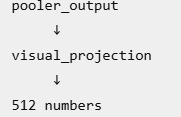

----------------------------------------------------------------
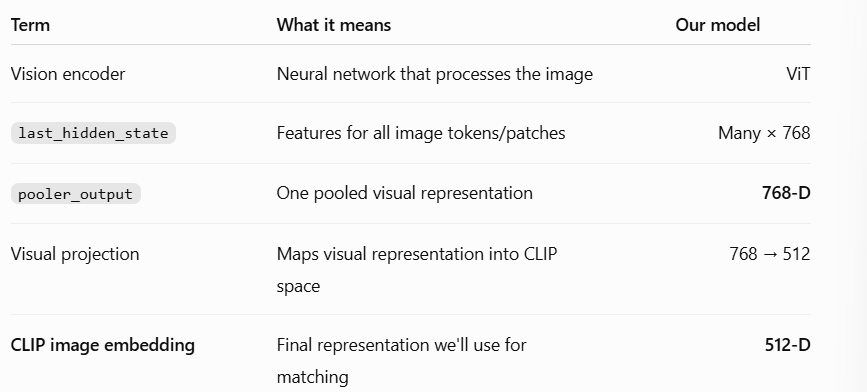


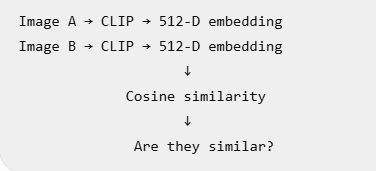

In [19]:
# Extract the projected CLIP image embedding
with torch.no_grad():
    vision_output = clip_model.vision_model(**inputs)
    image_features = clip_model.visual_projection(vision_output.pooler_output)

print("Embedding shape:", image_features.shape)

Embedding shape: torch.Size([1, 512])


In [20]:
# Generate normalized CLIP embeddings for all unique Shopee images
import time
import numpy as np
from tqdm.auto import tqdm

BATCH_SIZE = 32

clip_embeddings = []
clip_valid_image_names = []

start_time = time.time()

for start in tqdm(range(0, len(image_names), BATCH_SIZE)):
    batch_names = image_names[start:start + BATCH_SIZE]

    batch_images = []
    valid_names = []

    for image_name in batch_names:
        try:
            image_path = IMAGE_DIR / image_name
            image = Image.open(image_path).convert("RGB")
            batch_images.append(image)
            valid_names.append(image_name)
        except Exception as e:
            print(f"Skipping {image_name}: {e}")

    if not batch_images:
        continue

    inputs = clip_processor(
        images=batch_images,
        return_tensors="pt"
    )

    with torch.no_grad():
        vision_output = clip_model.vision_model(**inputs)
        batch_features = clip_model.visual_projection(
            vision_output.pooler_output
        )

    batch_features = torch.nn.functional.normalize(
        batch_features,
        p=2,
        dim=1
    )

    clip_embeddings.append(batch_features.cpu().numpy())
    clip_valid_image_names.extend(valid_names)

clip_embeddings = np.vstack(clip_embeddings)

elapsed_time = time.time() - start_time

print("Embedding matrix shape:", clip_embeddings.shape)
print("Valid images:", len(clip_valid_image_names))
print(f"Embedding generation time: {elapsed_time:.2f} seconds")

100%|██████████| 1013/1013 [22:44<00:00,  1.35s/it]

Embedding matrix shape: (32412, 512)
Valid images: 32412
Embedding generation time: 1364.34 seconds


### Computational Observations

- CLIP generated 512-dimensional embeddings for all **32,412 unique images**.
- Embedding generation took **1,364.34 seconds (22.74 minutes)** on the available CPU.
- The resulting embedding matrix has shape **(32,412, 512)**.
- Compared with ResNet50's 2,048-dimensional embeddings, CLIP requires approximately **one-fourth of the storage** for the embedding matrix.
- However, CLIP embedding generation was computationally expensive on CPU, highlighting the importance of batching and hardware acceleration for large-scale image matching.

In [21]:
# Calculate cosine similarity for every image pair using CLIP embeddings
clip_embedding_lookup = {
    image_name: embedding
    for image_name, embedding in zip(
        clip_valid_image_names,
        clip_embeddings
    )
}

clip_A = np.stack([
    clip_embedding_lookup[name]
    for name in image_pairs["image_A"]
])

clip_B = np.stack([
    clip_embedding_lookup[name]
    for name in image_pairs["image_B"]
])

clip_similarities = np.sum(clip_A * clip_B, axis=1)

image_pairs["clip_similarity"] = clip_similarities

print("CLIP similarities calculated:", len(clip_similarities))
print(image_pairs[["actual", "clip_similarity"]].head(10))

CLIP similarities calculated: 22028
   actual  clip_similarity
0       0         0.490698
1       0         0.473219
2       1         0.862347
3       0         0.421600
4       0         0.693054
5       1         0.698361
6       1         0.752273
7       0         0.317407
8       0         0.635538
9       1         0.635186


In [22]:
# Summarize CLIP similarity distributions for positive and negative pairs
print(
    image_pairs.groupby("actual")["clip_similarity"]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

        count      mean       std       min    median       max
actual                                                         
0       11014  0.455374  0.096727  0.108608  0.453568  0.887055
1       11014  0.789254  0.142820  0.243035  0.791815  1.000000


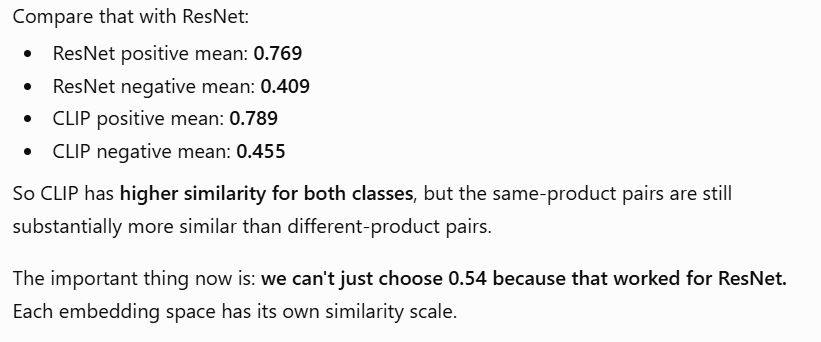

### Threshold Analysis

In [23]:
# Find the best CLIP matching threshold
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.96, 0.02)

clip_results = []

for threshold in thresholds:
    predictions = (
        image_pairs["clip_similarity"] >= threshold
    ).astype(int)

    precision = precision_score(image_pairs["actual"], predictions)
    recall = recall_score(image_pairs["actual"], predictions)
    f1 = f1_score(image_pairs["actual"], predictions)

    clip_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

clip_results = pd.DataFrame(clip_results)

print(
    clip_results
    .sort_values("f1", ascending=False)
    .head(10)
)

    threshold  precision    recall        f1
25       0.60   0.929141  0.900036  0.914357
24       0.58   0.903200  0.922553  0.912774
26       0.62   0.948388  0.875885  0.910696
23       0.56   0.869452  0.937262  0.902084
27       0.64   0.964530  0.844380  0.900465
22       0.54   0.835140  0.951153  0.889379
28       0.66   0.975591  0.809243  0.884665
21       0.52   0.795630  0.962139  0.870998
29       0.68   0.982523  0.770746  0.863845
20       0.50   0.755062  0.971763  0.849815


### Observations

- CLIP produced a clear separation between positive and negative image pairs, with mean cosine similarities of **0.7893** for same-product pairs and **0.4554** for different-product pairs.
- The best threshold was **0.60**, giving **92.91% precision**, **90.00% recall**, and an **F1-score of 91.44%**.
- Compared with the ResNet50 baseline (F1 = 89.33%), CLIP improved F1 by approximately **2.11 percentage points**.
- CLIP also improved both precision and recall, suggesting that its image representation is useful for distinguishing product identity in this dataset.
- The optimal threshold differs from ResNet50's threshold of 0.54 because the two models produce embeddings with different similarity distributions.
- Despite the improved matching performance, CLIP required substantially more computation for embedding generation on CPU, taking **1,364.34 seconds (22.74 minutes)** for 32,412 images.
- Overall, CLIP provides better matching performance than ResNet50 in this experiment, but at a significantly higher embedding-generation cost.

In [24]:
# Inspect CLIP performance at the best threshold
from sklearn.metrics import confusion_matrix

best_clip_threshold = 0.60

clip_predictions = (
    image_pairs["clip_similarity"] >= best_clip_threshold
).astype(int)

cm = confusion_matrix(
    image_pairs["actual"],
    clip_predictions
)

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

Confusion Matrix:
[[10258   756]
 [ 1101  9913]]

TP: 9913
FP: 756
TN: 10258
FN: 1101


### Confusion Matrix Observations

At the selected threshold of **0.60**, CLIP produced:

- **9,913 true positives**, correctly identifying same-product pairs.
- **10,258 true negatives**, correctly rejecting different-product pairs.
- **756 false positives**, where different products were incorrectly classified as matches.
- **1,101 false negatives**, where same products were incorrectly rejected.

Compared with the ResNet50 baseline, CLIP reduced false positives from **1,127 to 756** and false negatives from **1,214 to 1,101**.

The reduction in false positives is particularly important for product matching because it means CLIP is less likely to incorrectly treat visually similar but different products as the same product at its selected threshold.

# Nearest-Neighbor Analysis

**Given this product image, what are the most visually similar products in the entire dataset**

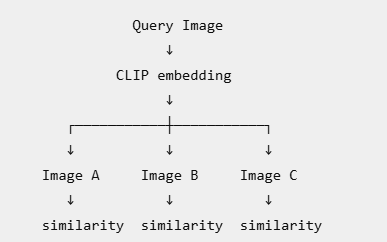



### Steps

1. **Select query products**
   - Choose a small set of representative product images for analysis.

2. **Obtain image embeddings**
   - Use the pretrained CLIP image encoder to represent each query image as a 512-dimensional embedding.

3. **Search for similar products**
   - Compare the query embedding with the embeddings of all other images using cosine similarity.
   - Retrieve the **Top-K most similar images**.

4. **Exclude the query image**
   - Remove the query image itself from the retrieved results since it will have the highest possible similarity.

5. **Compare retrieved products with the true product group**
   - Use `label_group` to determine whether each retrieved image actually belongs to the same product as the query.

6. **Visualize the results**
   - Display the query image alongside its Top-K nearest neighbors.
   - Show the similarity score and product group for each retrieved image.

7. **Analyze the retrievals**
   - Identify cases where the nearest neighbors correctly correspond to the same product.
   - Identify cases where visually similar but different products are retrieved.
   - Use these observations to motivate the subsequent error analysis.

In [25]:
# Select three query images from product groups with multiple listings
query_groups = (
    train.groupby("label_group")
    .filter(lambda group: len(group) >= 3)
    .groupby("label_group")
    .head(1)
)

query_images = query_groups.head(3)[
    ["posting_id", "image", "label_group", "title"]
].reset_index(drop=True)

print(query_images[["posting_id", "image", "label_group"]])

         posting_id                                 image  label_group
0  train_2464356923  0013e7355ffc5ff8fb1ccad3e42d92fe.jpg   2660605217
1  train_1802986387  00144a49c56599d45354a1c28104c039.jpg   1835033137
2    train_86570404  0019a3c6755a194cb2e2c12bfc63972e.jpg   2359912463


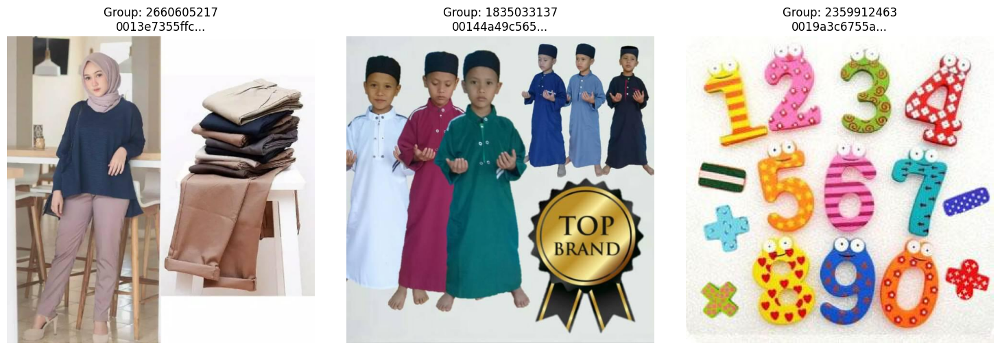

In [26]:
# Display the three selected query images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (_, row) in zip(axes, query_images.iterrows()):
    image = Image.open(IMAGE_DIR / row["image"]).convert("RGB")
    
    ax.imshow(image)
    ax.set_title(
        f"Group: {row['label_group']}\n{row['image'][:12]}..."
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Query 1

In [27]:
# Retrieve the top-5 CLIP nearest neighbors for Query 1
from sklearn.neighbors import NearestNeighbors

query_image = query_images.iloc[0]["image"]

query_index = clip_valid_image_names.index(query_image)

nn_model = NearestNeighbors(
    n_neighbors=6,
    metric="cosine",
    algorithm="brute"
)

nn_model.fit(clip_embeddings)

distances, indices = nn_model.kneighbors(
    clip_embeddings[query_index].reshape(1, -1)
)

neighbor_indices = indices[0]
neighbor_distances = distances[0]

# Convert cosine distance to cosine similarity
neighbor_similarities = 1 - neighbor_distances

# Remove the query image itself
results = []

for idx, similarity in zip(
    neighbor_indices,
    neighbor_similarities
):
    image_name = clip_valid_image_names[idx]

    if image_name == query_image:
        continue

    row = train[train["image"] == image_name].iloc[0]

    results.append({
        "rank": len(results) + 1,
        "image": image_name,
        "similarity": similarity,
        "label_group": row["label_group"],
        "posting_id": row["posting_id"]
    })

    if len(results) == 5:
        break

query1_neighbors = pd.DataFrame(results)

print("Query image:", query_image)
print("Query group:", query_images.iloc[0]["label_group"])
print()
print(query1_neighbors)

Query image: 0013e7355ffc5ff8fb1ccad3e42d92fe.jpg
Query group: 2660605217

   rank                                 image  similarity  label_group  \
0     1  0b5b2b2b3f84721140a7e18c2e43a4ff.jpg    0.918906   2660605217   
1     2  16643489d5029d67cbaa527a69514b6e.jpg    0.850599   3085681416   
2     3  f0524e230f2e78303b9693d585be63e4.jpg    0.844299   1927840651   
3     4  725671ab39686cc2d78e3c4a5a7a4480.jpg    0.842228   3946393392   
4     5  f792a55aa2552dbbab4473ebe4f5ea13.jpg    0.841598     48363793   

         posting_id  
0  train_2753295474  
1  train_1715965184  
2  train_1179304308  
3  train_2373823959  
4  train_2277308546  


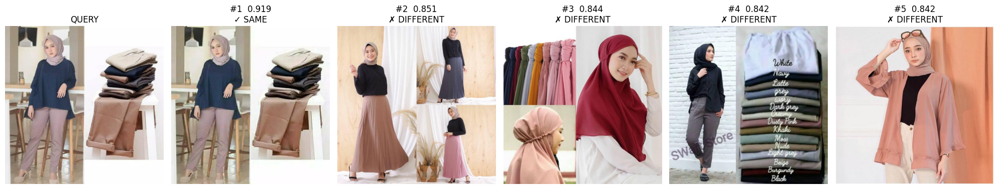

In [28]:
# Visualize Query 1 and its five nearest CLIP neighbors
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

# Query image
query_row = query_images.iloc[0]
query_img = Image.open(
    IMAGE_DIR / query_row["image"]
).convert("RGB")

axes[0].imshow(query_img)
axes[0].set_title("QUERY")
axes[0].axis("off")

# Nearest neighbors
for ax, (_, row) in zip(
    axes[1:],
    query1_neighbors.iterrows()
):
    img = Image.open(
        IMAGE_DIR / row["image"]
    ).convert("RGB")

    same_group = row["label_group"] == query_row["label_group"]
    marker = "✓ SAME" if same_group else "✗ DIFFERENT"

    ax.imshow(img)
    ax.set_title(
        f"#{row['rank']}  {row['similarity']:.3f}\n{marker}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Query 1 Observations

- The highest-ranked neighbor belongs to the same `label_group` as the query, with a cosine similarity of **0.919**, indicating a successful retrieval.
- The remaining four nearest neighbors belong to different product groups, despite having high similarities between **0.842 and 0.851**.
- The retrieved images share strong visual characteristics with the query, including similar clothing styles, model-based product photography, poses, and color palettes.
- ***This demonstrates that high visual similarity does not always imply the same product identity.***
- The result also highlights a key challenge in image-based product matching: distinguishing different products that share similar visual appearance.

### Query 2

In [29]:
# Retrieve the top-5 CLIP nearest neighbors for Query 2
query_image = query_images.iloc[1]["image"]
query_index = clip_valid_image_names.index(query_image)

distances, indices = nn_model.kneighbors(
    clip_embeddings[query_index].reshape(1, -1)
)

results = []

for idx, distance in zip(indices[0], distances[0]):
    image_name = clip_valid_image_names[idx]

    if image_name == query_image:
        continue

    row = train[train["image"] == image_name].iloc[0]

    results.append({
        "rank": len(results) + 1,
        "image": image_name,
        "similarity": 1 - distance,
        "label_group": row["label_group"],
        "posting_id": row["posting_id"]
    })

    if len(results) == 5:
        break

query2_neighbors = pd.DataFrame(results)

print("Query image:", query_image)
print("Query group:", query_images.iloc[1]["label_group"])
print()
print(query2_neighbors)

Query image: 00144a49c56599d45354a1c28104c039.jpg
Query group: 1835033137

   rank                                 image  similarity  label_group  \
0     1  f1d095e8b48623f48125567e8c7959e3.jpg    0.811821   3698252718   
1     2  5fe85bab13c3c374e4762e3274b41387.jpg    0.799488    774162729   
2     3  2cec6c38f97ff1ccba72c697c54e0185.jpg    0.746436   3250698869   
3     4  e44ec63d3f408c46ca218f44bbd3ab7f.jpg    0.745486   3464246482   
4     5  a4197e89cb3f25d8814e4eb1d332bd4e.jpg    0.744417    774162729   

         posting_id  
0  train_1513994777  
1   train_944158112  
2  train_2014756510  
3   train_318335005  
4  train_3009831124  


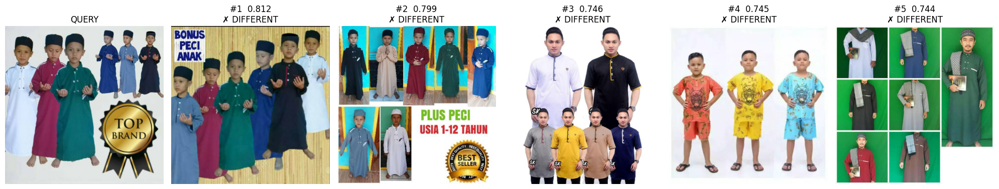

In [30]:
# Visualize Query 2 and its five nearest CLIP neighbors
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

query_row = query_images.iloc[1]
query_img = Image.open(
    IMAGE_DIR / query_row["image"]
).convert("RGB")

axes[0].imshow(query_img)
axes[0].set_title("QUERY")
axes[0].axis("off")

for ax, (_, row) in zip(
    axes[1:],
    query2_neighbors.iterrows()
):
    img = Image.open(
        IMAGE_DIR / row["image"]
    ).convert("RGB")

    same_group = row["label_group"] == query_row["label_group"]
    marker = "✓ SAME" if same_group else "✗ DIFFERENT"

    ax.imshow(img)
    ax.set_title(
        f"#{row['rank']}  {row['similarity']:.3f}\n{marker}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Query 2 Observations

- None of the Top-5 nearest neighbors belong to the query's true `label_group`, so this query represents an unsuccessful exact-product retrieval.
- Despite this, all retrieved images are visually related to the query and contain children's clothing with similar colors, poses, and product presentation.
- The highest-ranked neighbor has a similarity of **0.812**, showing that a high CLIP similarity does not necessarily indicate the same product.
- CLIP appears to capture the broader semantic concept of children's traditional clothing rather than distinguishing the exact product identity.
- This demonstrates a limitation of semantic image representations for fine-grained product matching, where visually similar products from different groups must be separated.

### Query 3

In [31]:
# Retrieve the top-5 CLIP nearest neighbors for Query 3
query_image = query_images.iloc[2]["image"]
query_index = clip_valid_image_names.index(query_image)

distances, indices = nn_model.kneighbors(
    clip_embeddings[query_index].reshape(1, -1)
)

results = []

for idx, distance in zip(indices[0], distances[0]):
    image_name = clip_valid_image_names[idx]

    if image_name == query_image:
        continue

    row = train[train["image"] == image_name].iloc[0]

    results.append({
        "rank": len(results) + 1,
        "image": image_name,
        "similarity": 1 - distance,
        "label_group": row["label_group"],
        "posting_id": row["posting_id"]
    })

    if len(results) == 5:
        break

query3_neighbors = pd.DataFrame(results)

print("Query image:", query_image)
print("Query group:", query_images.iloc[2]["label_group"])
print()
print(query3_neighbors)

Query image: 0019a3c6755a194cb2e2c12bfc63972e.jpg
Query group: 2359912463

   rank                                 image  similarity  label_group  \
0     1  247fb6f523a663c3333ef1c923ec7b51.jpg    0.898722   2359912463   
1     2  7d2ce94f2ead9baa11748c736311279d.jpg    0.884672   2196920644   
2     3  d9482c818761f42056888072d6d0ade1.jpg    0.859233   2196920644   
3     4  4741d624eee27f78e944450390957af0.jpg    0.856059   1905943612   
4     5  ccb93b8dd0d6588e17b559c776735118.jpg    0.854596   1905943612   

         posting_id  
0  train_2837452969  
1  train_2459562529  
2  train_1616715300  
3  train_3760839674  
4  train_4094900766  


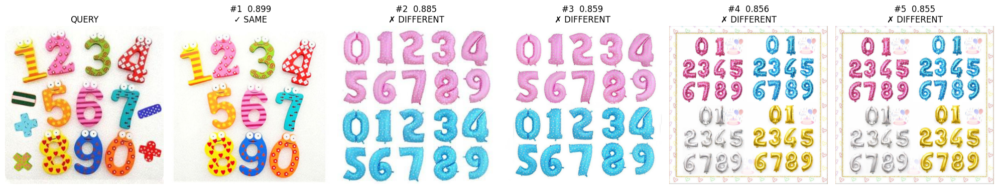

In [32]:
# Visualize Query 3 and its five nearest CLIP neighbors
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

query_row = query_images.iloc[2]
query_img = Image.open(
    IMAGE_DIR / query_row["image"]
).convert("RGB")

axes[0].imshow(query_img)
axes[0].set_title("QUERY")
axes[0].axis("off")

for ax, (_, row) in zip(
    axes[1:],
    query3_neighbors.iterrows()
):
    img = Image.open(
        IMAGE_DIR / row["image"]
    ).convert("RGB")

    same_group = row["label_group"] == query_row["label_group"]
    marker = "✓ SAME" if same_group else "✗ DIFFERENT"

    ax.imshow(img)
    ax.set_title(
        f"#{row['rank']}  {row['similarity']:.3f}\n{marker}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

### Query 3 Observations

- The highest-ranked neighbor belongs to the same `label_group` as the query, with a cosine similarity of **0.899**, resulting in a successful top-1 retrieval.
- The remaining four neighbors belong to different product groups but have high similarities ranging from **0.855 to 0.885**.
- The incorrect neighbors are visually very similar to the query, containing colorful number-shaped objects with similar layouts and presentation.
- This shows that CLIP can successfully identify the general product type, but distinguishing between different designs or variants of visually similar products remains challenging.
- The high similarity of these different products demonstrates why product matching requires finer-grained identity discrimination rather than only broad visual similarity.

# ERROR ANALYSIS

We will inspect three cases

1) False Positives
    - different products with similar appearance
    - similar colors/designs
    - different variants
    - similar packaging

    - 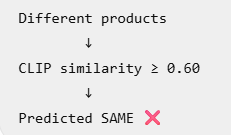

2) Extreme False Negatives
    - different photography
    - different background
    - different crop
    - different angle
    - packaging changes
    - low-quality images

    - 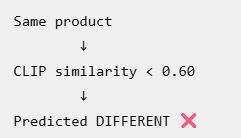

3) BorderLine False Negatives
    - False Negative pairs with similarity just below threshold


## Finding Strongest False Positives pairs

In [33]:
# Find the highest-similarity false-positive image pairs
false_positives = image_pairs[
    (image_pairs["actual"] == 0) &
    (image_pairs["clip_similarity"] >= best_clip_threshold)
].copy()

false_positives = (
    false_positives
    .sort_values("clip_similarity", ascending=False)
    .reset_index(drop=True)
)

print("Number of false positives:", len(false_positives))
print(
    false_positives[
        ["image_A", "image_B", "clip_similarity"]
    ].head(10)
)

Number of false positives: 756
                                image_A                               image_B  \
0  bed186d6a089d747abe7c31ff76c2102.jpg  24f1ce35b26214cf6d603443a5d4d7fe.jpg   
1  e4608a81e52f7f1f523d8846dfa91870.jpg  40b98946a1ba9726ff4f843e9a6b75f3.jpg   
2  4a2dba63d25eb930bb9e6b418db85441.jpg  a30e83fc5d0f6458441d9a82f5dd6290.jpg   
3  235b59afa551c68d3fd81b8ac6b8f035.jpg  c39dcbe49602b76914e55eb602fdaa03.jpg   
4  8c83f189d7fc030e8aa5b36f272d40ff.jpg  06419a00c252e4a3c97c9a2861477526.jpg   
5  7c0f3b8bdacde8d488b74091dcb5d5e0.jpg  bf48d5d27e1f0257a9f9b7ae8c55692a.jpg   
6  456da605a4d11f23d06e394fa599dab7.jpg  885bd4ff28cf07452fd71c8991ac93e1.jpg   
7  06423ee30eb15bfb729e12420c07ed31.jpg  8d3e3e2cac880d95b320564202a92d4a.jpg   
8  2e5e4a75f015fff1b72778f10f191f76.jpg  3e3f7d12a82c0b108581a4d689e96d92.jpg   
9  1aff65e64f3b6e0f02bbaa97a3ac1bc2.jpg  704a94f1b9cfab0a7ee2896ebc0a6840.jpg   

   clip_similarity  
0         0.887055  
1         0.819611  
2         0.81

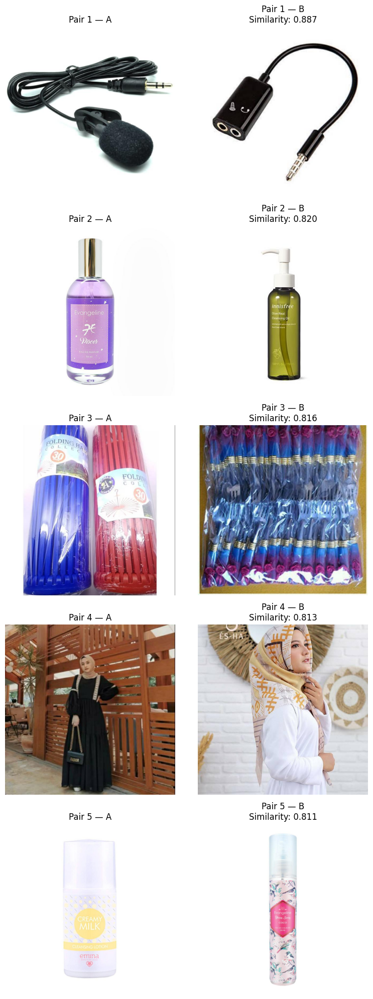

In [34]:
# Visualize the five strongest CLIP false-positive pairs
top_fp = false_positives.head(5)

fig, axes = plt.subplots(5, 2, figsize=(8, 20))

for i, (_, row) in enumerate(top_fp.iterrows()):
    image_a = Image.open(
        IMAGE_DIR / row["image_A"]
    ).convert("RGB")

    image_b = Image.open(
        IMAGE_DIR / row["image_B"]
    ).convert("RGB")

    axes[i, 0].imshow(image_a)
    axes[i, 0].set_title(
        f"Pair {i+1} — A"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image_b)
    axes[i, 1].set_title(
        f"Pair {i+1} — B\nSimilarity: {row['clip_similarity']:.3f}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

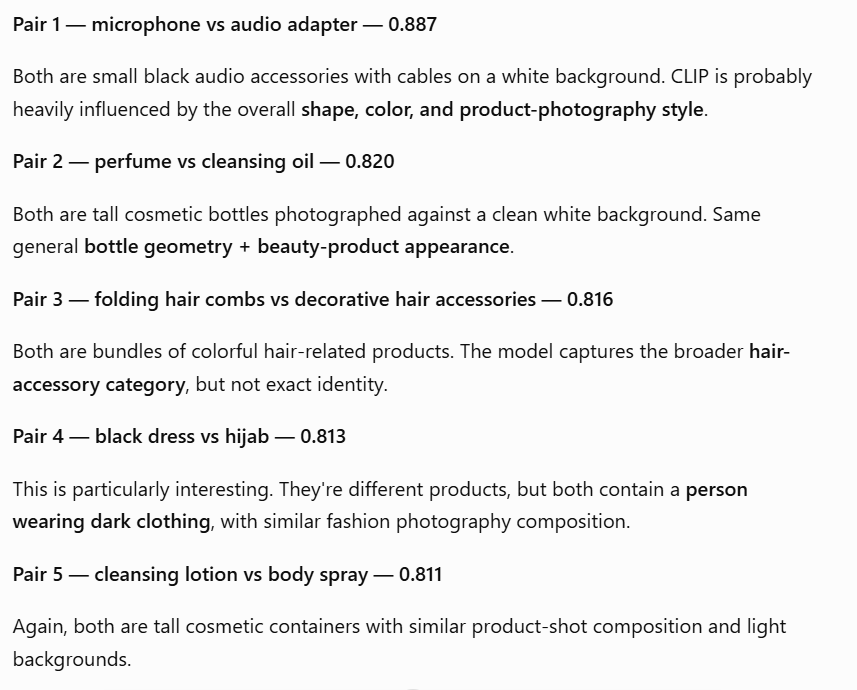

### False Positive Analysis

The strongest false positives reveal several recurring patterns:

- **Similar product category:** Different products from the same broad category, such as cosmetics or hair accessories, can receive high similarity scores.
- **Similar shape and appearance:** Products with similar bottle shapes, colors, or physical structures can be confused even when their identities differ.
- **Similar product photography:** Images with clean white backgrounds and similar product-shot compositions can produce high similarity.
- **Similar fashion composition:** Images containing people wearing clothing or accessories can be considered similar even when the actual products are different.
- The highest false-positive similarity was **0.887**, showing that some different products are extremely close in the CLIP embedding space.
- Overall, the false positives suggest that CLIP captures broad visual and semantic characteristics effectively, but can struggle with **fine-grained product identity**.

## Finding Lowest Similarity false- Nagative pairs

In [35]:
# Find the lowest-similarity false-negative image pairs
false_negatives = image_pairs[
    (image_pairs["actual"] == 1) &
    (image_pairs["clip_similarity"] < best_clip_threshold)
].copy()

false_negatives = (
    false_negatives
    .sort_values("clip_similarity", ascending=True)
    .reset_index(drop=True)
)

print("Number of false negatives:", len(false_negatives))
print(
    false_negatives[
        ["image_A", "image_B", "clip_similarity"]
    ].head(10)
)

Number of false negatives: 1101
                                image_A                               image_B  \
0  d9afc7c5ba3d6cbe60d76849617e1ef3.jpg  2eb6a31c068cb6ef7d6702133e61e07e.jpg   
1  5bfc3b29376b2692c79a0f91dbea437e.jpg  0b760b1382cefc938a5275bec4b9c8f2.jpg   
2  e0c787d5990bec17a8ba17a8acd6a941.jpg  3b4f5beec20f6248a78dda2a1b58992c.jpg   
3  76be7078d1d94e9953369117a19a432b.jpg  5831e3b0c1c9ba41dc1d4faa2fc13020.jpg   
4  47a5074f91558926a479fd9da67f6dee.jpg  136456ad3240d6ea18d445f332a50471.jpg   
5  45e26fc9aaea6d0e813abd13cb9c2104.jpg  3f05f86f294eb04df605c0d9fb6ae84a.jpg   
6  f1bd21798ef409957ffd5876c455f33a.jpg  5097b332c0bf0397396c65b1d8cedf8d.jpg   
7  4f6d9369c02e3b6d26613e5f648934bc.jpg  18182ca260def18b653f515ab2554541.jpg   
8  87b10a40b9a61ff55cd94eb821b5662d.jpg  bc0ea8e107ee33e6907bcc701c94dfbb.jpg   
9  bfb84f8547f15613c2c56e927fe8864a.jpg  0061fff53b6eba569fb383da29fdcb47.jpg   

   clip_similarity  
0         0.243035  
1         0.248974  
2         0.2

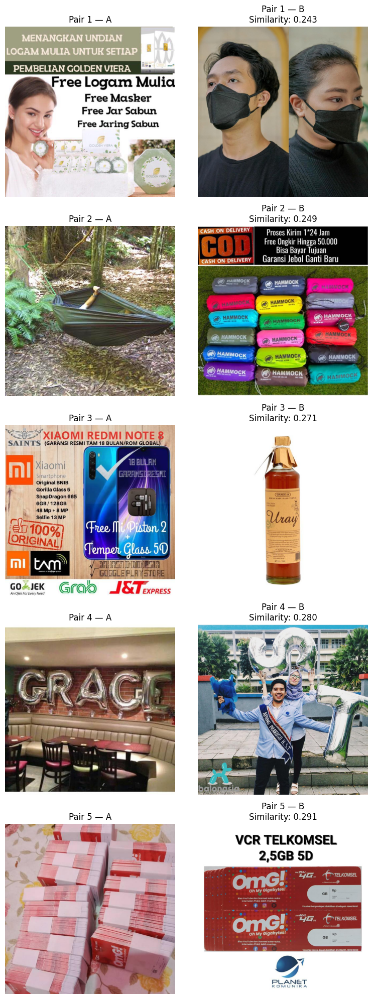

In [36]:
# Visualize the five hardest CLIP false-negative pairs
top_fn = false_negatives.head(5)

fig, axes = plt.subplots(5, 2, figsize=(8, 20))

for i, (_, row) in enumerate(top_fn.iterrows()):
    image_a = Image.open(
        IMAGE_DIR / row["image_A"]
    ).convert("RGB")

    image_b = Image.open(
        IMAGE_DIR / row["image_B"]
    ).convert("RGB")

    axes[i, 0].imshow(image_a)
    axes[i, 0].set_title(f"Pair {i+1} — A")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image_b)
    axes[i, 1].set_title(
        f"Pair {i+1} — B\nSimilarity: {row['clip_similarity']:.3f}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


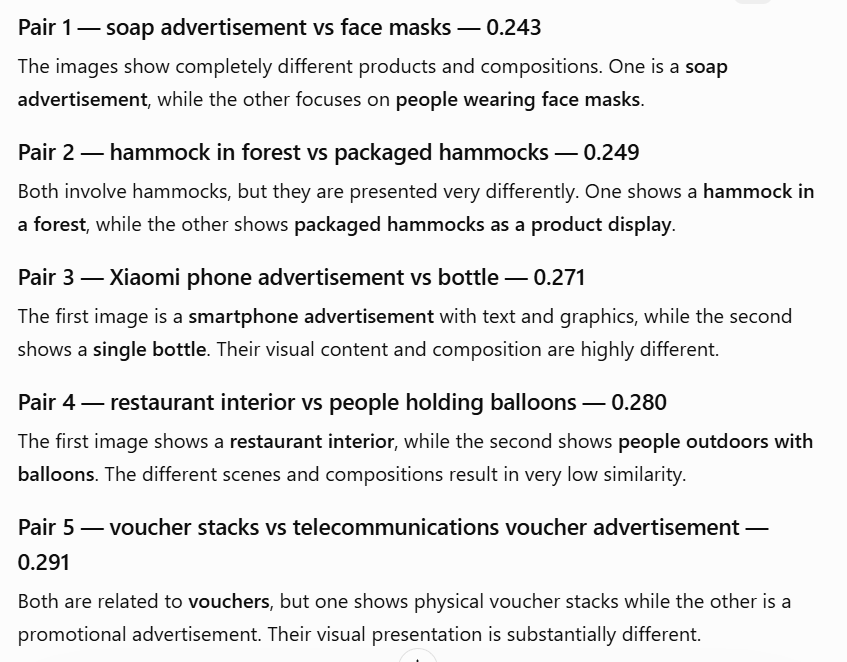

### False Negative Analysis

The hardest false negatives reveal an important limitation in the evaluation data as well as in the model.

- There are **1,101 false negatives** at the CLIP threshold of 0.60.
- The five lowest-similarity positive pairs have similarities ranging from **0.243 to 0.291**.
- Several of these pairs appear visually unrelated despite sharing the same `label_group`. For example, some pairs contain completely different products or very different image content.
- This suggests that some `label_group` assignments may contain noisy or visually inconsistent listings, making exact image-based matching difficult even when the dataset labels the pair as a positive match.
- Therefore, not all false negatives can be attributed to changes in viewpoint, background, cropping, or image quality. Some may reflect limitations or ambiguity in the ground-truth grouping itself.
- This highlights an important limitation of evaluating image matching solely using `label_group`: the label may not always correspond perfectly to visual product identity.

## find borderline false negatives

In [37]:
# Find false negatives closest to the CLIP matching threshold
borderline_fn = image_pairs[
    (image_pairs["actual"] == 1) &
    (image_pairs["clip_similarity"] < best_clip_threshold)
].copy()

borderline_fn["distance_from_threshold"] = (
    best_clip_threshold - borderline_fn["clip_similarity"]
)

borderline_fn = (
    borderline_fn
    .sort_values("distance_from_threshold")
    .reset_index(drop=True)
)

print(
    borderline_fn[
        ["image_A", "image_B", "clip_similarity"]
    ].head(10)
)

                                image_A                               image_B  \
0  fb9885c20d4d0e893d4eabb56f3e0b41.jpg  d852317439f4dd71a2775400cdabfe6e.jpg   
1  dfae2be5f94dadbfb2547798abe547ac.jpg  17c5df5e0cfcb63bc5f0d002a2c11bce.jpg   
2  ebfc8f689451e36bc48b0ad9d6882b66.jpg  741f58929af917f36ebbef24f8f2dd1d.jpg   
3  2ff5b82bbf2419434614eb4c47664194.jpg  394498fb42827673ba7fbdc0db0acd11.jpg   
4  e2e042228e57db9bff99c8ff49428046.jpg  5e38f1a6479cbfc5b9e9c4057f8413c1.jpg   
5  ca52a39719d9df694f60084089890da0.jpg  3ff84314cbc836ac821d24bf7f97d8fd.jpg   
6  7334f33a7286b420ce07e8319a217ca0.jpg  0d1c2ef01101c5935c85bca9fc282a4a.jpg   
7  1ce5f5519eaa5a859ee0eda6339c232e.jpg  22c6afc1d400ff93e2e0996002e97268.jpg   
8  7c016fd1309674cb648b498f8535cbef.jpg  caf2806177eea6cb865f246c6da85f3f.jpg   
9  29fd735390a44bb3db0915806f2ae04c.jpg  7e4561f1bbb148c24c0cdb17e7f3529a.jpg   

   clip_similarity  
0         0.600000  
1         0.599875  
2         0.599703  
3         0.599532  
4  

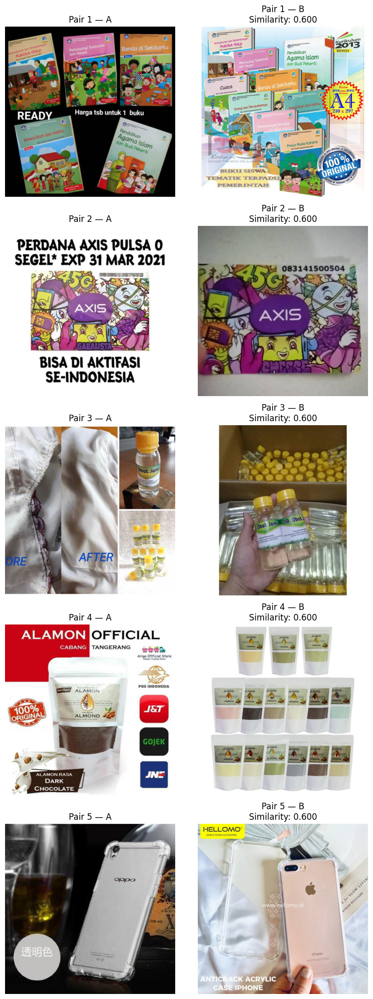

In [38]:
# Visualize the five borderline false-negative pairs
top_borderline_fn = borderline_fn.head(5)

fig, axes = plt.subplots(5, 2, figsize=(8, 20))

for i, (_, row) in enumerate(top_borderline_fn.iterrows()):
    image_a = Image.open(
        IMAGE_DIR / row["image_A"]
    ).convert("RGB")

    image_b = Image.open(
        IMAGE_DIR / row["image_B"]
    ).convert("RGB")

    axes[i, 0].imshow(image_a)
    axes[i, 0].set_title(f"Pair {i+1} — A")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image_b)
    axes[i, 1].set_title(
        f"Pair {i+1} — B\nSimilarity: {row['clip_similarity']:.3f}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

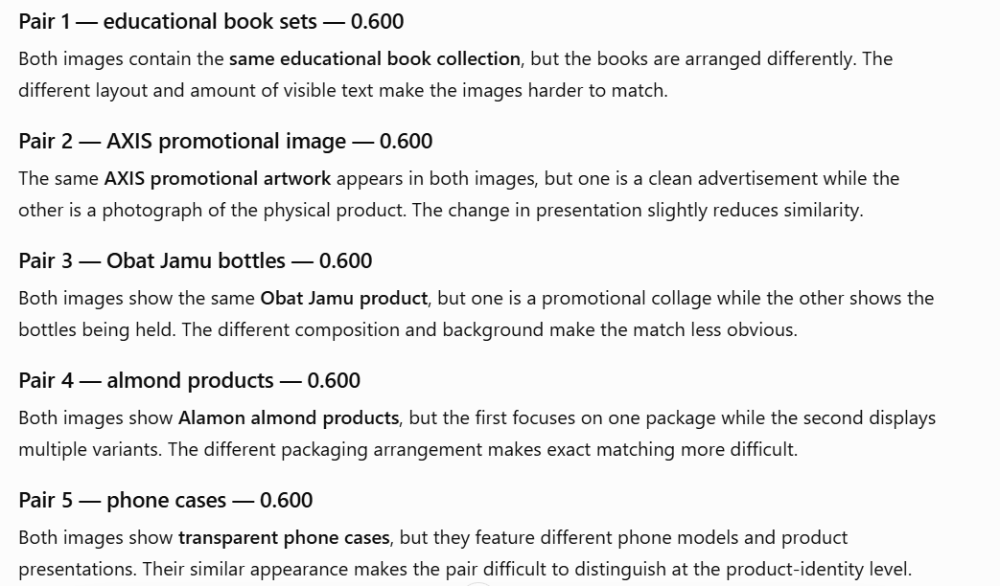



### Observations

- Borderline false negatives show that CLIP can struggle when the **same product is presented in different formats**, such as a collage versus a product photo.
- Changes in **layout, background, packaging arrangement, and image composition** can reduce similarity even when the product is recognizable.
- Some pairs contain **multiple variants or products**, making exact product identity harder to distinguish.
- Since these examples lie very close to the **0.60 threshold**, small changes in the threshold can change their classification.
- Overall, these cases highlight the **precision–recall trade-off** when choosing the matching threshold.

## Final Conclusion

- Two pretrained image representations were evaluated for product matching: **ResNet50** and **CLIP**.

- ResNet50 produced **2,048-dimensional embeddings** and achieved an F1-score of **89.33%** at a threshold of **0.54**.
- CLIP produced more compact **512-dimensional embeddings** and achieved a higher F1-score of **91.44%** at a threshold of **0.60**, with improvements in both precision and recall.
- CLIP reduced false positives from **1,127 to 756**, showing better discrimination between visually similar but different products in this evaluation.
- Nearest-neighbor analysis showed that CLIP can successfully retrieve the same product, but it can also retrieve different products with very similar visual characteristics.
- Error analysis showed that false positives often arise from **similar product categories, shapes, colors, and photography styles**, while false negatives can occur when the same product is presented with substantially different layouts or visual content.
- Some false-negative examples also appeared visually inconsistent despite sharing the same `label_group`, highlighting a possible limitation of using the dataset grouping as the sole ground truth for image-based matching.
- Overall, **CLIP provided the stronger matching representation**, while ResNet50 offered a substantially simpler and faster feature-extraction baseline on the available hardware.
- The experiments demonstrate that pretrained image embeddings can provide effective product matching without training a vision model from scratch, but **fine-grained product identity remains challenging when visual similarity and product identity do not perfectly align**.